# OcuSense Metadata Model (model1.ipynb)
This notebook implements the training and evaluation pipeline for the **OcuSense Metadata Model**.
While baseline models (v1-v7) leverage deep convolutional neural networks to classify eye conditions from retinal fundus scans, the metadata model explores the predictive power of **patient demographics and clinical keywords** alone.

### Objective:
Predict the eye condition among 6 merged classes:
1. **Normal (N)**
2. **Diabetic Retinopathy (D)**
3. **Glaucoma (G)**
4. **Cataract (C)**
5. **Myopia (M)**
6. **Other (O)** (merging AMD, Hypertensive Retinopathy, and Other)

### Features:
1. **Patient Age** (Numerical, Standardized)
2. **Patient Sex** (Categorical, One-Hot Encoded)
3. **Diagnostic Keyword** (Textual, TF-IDF Vectorized) - derived from Left/Right Diagnostic Keywords depending on the fundus eye image corresponding to the row.

### Methodology:
- **Leakage-Free Patient-Level Split**: 70% Train, 15% Validation, 15% Test.
- **Model Comparison**: Random Forest, Gradient Boosting (HistGradientBoosting), and a PyTorch Deep Multi-Layer Perceptron (MLP).
- **Imbalance Mitigation**: Class-weighted losses/criteria.

In [1]:
import os
import ast
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# Set seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Environment setup and libraries imported successfully!")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Environment setup and libraries imported successfully!
Using device: cpu


In [2]:
# Constants
CSV_PATH = r"C:\Users\gaura\Desktop\Eye Disease Detection\ocular-disease-recognition-odir5k\full_df.csv"

# Load the dataset
df = pd.read_csv(CSV_PATH)
print(f"Loaded ODIR dataset with shape: {df.shape}")

# Handle class merging
MERGE_MAP = {
    'N': 0, 'D': 1, 'G': 2, 'C': 3, 'M': 4,
    'A': 5, 'H': 5, 'O': 5
}
df['label_str'] = df['labels'].apply(lambda x: ast.literal_eval(x)[0])
df['label_encoded'] = df['label_str'].apply(lambda x: MERGE_MAP[x])

# Extract correct eye diagnostic keyword based on eye image side
df['diagnostic_keyword'] = df.apply(
    lambda row: row['Left-Diagnostic Keywords'] if 'left' in str(row['filename']) else row['Right-Diagnostic Keywords'],
    axis=1
)

# Handle missing values
df['Patient Age'] = df['Patient Age'].fillna(df['Patient Age'].median())
df['Patient Sex'] = df['Patient Sex'].fillna('Unknown')
df['diagnostic_keyword'] = df['diagnostic_keyword'].fillna('')

# Inspect the dataset
print("\nFirst few rows:")
display(df[['ID', 'Patient Age', 'Patient Sex', 'diagnostic_keyword', 'label_encoded']].head())

print("\nClass Distribution:")
class_names = ['Normal', 'Diabetic Retinopathy', 'Glaucoma', 'Cataract', 'Myopia', 'Other']
dist = df['label_encoded'].value_counts().sort_index()
for idx, count in dist.items():
    print(f"  {class_names[idx]:<25}: {count:<5} ({count/len(df)*100:.2f}%)")

Loaded ODIR dataset with shape: (6392, 19)

First few rows:


,ID,Patient Age,Patient Sex,diagnostic_keyword,label_encoded
0,0,69,Female,normal fundus,0
1,1,57,Male,normal fundus,0
2,2,42,Male,moderate non proliferative retinopathy,1
3,4,53,Male,mild nonproliferative retinopathy,1
4,5,50,Female,moderate non proliferative retinopathy,1



Class Distribution:
  Normal                   : 2873  (44.95%)
  Diabetic Retinopathy     : 1608  (25.16%)
  Glaucoma                 : 284   (4.44%)
  Cataract                 : 293   (4.58%)
  Myopia                   : 232   (3.63%)
  Other                    : 1102  (17.24%)


In [3]:
# Patient-Level Split with Leakage Check
unique_patients = df['ID'].unique()
print(f"Total unique patients : {len(unique_patients)}")

train_ids, temp_ids = train_test_split(unique_patients, test_size=0.30, random_state=SEED)
val_ids,   test_ids = train_test_split(temp_ids,        test_size=0.50, random_state=SEED)

train_df = df[df['ID'].isin(train_ids)].reset_index(drop=True)
val_df   = df[df['ID'].isin(val_ids)].reset_index(drop=True)
test_df  = df[df['ID'].isin(test_ids)].reset_index(drop=True)

print(f"Train samples: {len(train_df)} | Val samples: {len(val_df)} | Test samples: {len(test_df)}")

# Leakage checks
train_set = set(train_df['ID'])
val_set   = set(val_df['ID'])
test_set  = set(test_df['ID'])
print(f"\nLeakage Check:")
print(f"  Train & Val intersection  : {len(train_set & val_set)}  (Must be 0)")
print(f"  Train & Test intersection : {len(train_set & test_set)} (Must be 0)")
print(f"  Val & Test intersection   : {len(val_set & test_set)}  (Must be 0)")

Total unique patients : 3358
Train samples: 4473 | Val samples: 959 | Test samples: 960

Leakage Check:
  Train & Val intersection  : 0  (Must be 0)
  Train & Test intersection : 0 (Must be 0)
  Val & Test intersection   : 0  (Must be 0)


In [4]:
# Preprocessing pipeline setup
numerical_cols = ['Patient Age']
categorical_cols = ['Patient Sex']
text_col = 'diagnostic_keyword'

# Define preprocessing for numerical and categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Vectorizer for text
vectorizer = TfidfVectorizer(max_features=250, stop_words='english')

# Fit Preprocessors on training data
train_tabular = preprocessor.fit_transform(train_df[numerical_cols + categorical_cols])
train_text = vectorizer.fit_transform(train_df[text_col]).toarray()

# Transform Val and Test datasets
val_tabular = preprocessor.transform(val_df[numerical_cols + categorical_cols])
val_text = vectorizer.transform(val_df[text_col]).toarray()

test_tabular = preprocessor.transform(test_df[numerical_cols + categorical_cols])
test_text = vectorizer.transform(test_df[text_col]).toarray()

# Concatenate tabular and text features
X_train = np.hstack((train_tabular, train_text))
X_val   = np.hstack((val_tabular, val_text))
X_test  = np.hstack((test_tabular, test_text))

y_train = train_df['label_encoded'].values
y_val   = val_df['label_encoded'].values
y_test  = test_df['label_encoded'].values

print(f"Final feature shape (X_train): {X_train.shape}")
print(f"Final feature shape (X_val): {X_val.shape}")
print(f"Final feature shape (X_test): {X_test.shape}")

Final feature shape (X_train): (4473, 80)
Final feature shape (X_val): (959, 80)
Final feature shape (X_test): (960, 80)


In [5]:
# Random Forest Classifier
print("Training Random Forest Classifier...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=SEED, class_weight='balanced')
rf_model.fit(X_train, y_train)

# Val prediction
rf_val_preds = rf_model.predict(X_val)
rf_val_acc = accuracy_score(y_val, rf_val_preds)
rf_val_macro_f1 = f1_score(y_val, rf_val_preds, average='macro')

# Test prediction
rf_test_preds = rf_model.predict(X_test)
rf_test_acc = accuracy_score(y_test, rf_test_preds)
rf_test_macro_f1 = f1_score(y_test, rf_test_preds, average='macro')

print(f"\nRandom Forest Validation Accuracy: {rf_val_acc*100:.2f}% | Macro F1: {rf_val_macro_f1:.4f}")
print(f"Random Forest Test Accuracy       : {rf_test_acc*100:.2f}% | Macro F1: {rf_test_macro_f1:.4f}")
print("\nClassification Report (Test Set):")
print(classification_report(y_test, rf_test_preds, target_names=class_names))

Training Random Forest Classifier...



Random Forest Validation Accuracy: 97.18% | Macro F1: 0.9694
Random Forest Test Accuracy       : 98.44% | Macro F1: 0.9821

Classification Report (Test Set):
                      precision    recall  f1-score   support

              Normal       1.00      1.00      1.00       444
Diabetic Retinopathy       0.98      0.96      0.97       240
            Glaucoma       1.00      0.98      0.99        47
            Cataract       0.98      1.00      0.99        48
              Myopia       0.97      1.00      0.99        36
               Other       0.95      0.97      0.96       145

            accuracy                           0.98       960
           macro avg       0.98      0.98      0.98       960
        weighted avg       0.98      0.98      0.98       960



In [6]:
# Hist Gradient Boosting Classifier
print("Training Hist Gradient Boosting Classifier...")
hgb_model = HistGradientBoostingClassifier(random_state=SEED, class_weight='balanced')
hgb_model.fit(X_train, y_train)

# Val prediction
hgb_val_preds = hgb_model.predict(X_val)
hgb_val_acc = accuracy_score(y_val, hgb_val_preds)
hgb_val_macro_f1 = f1_score(y_val, hgb_val_preds, average='macro')

# Test prediction
hgb_test_preds = hgb_model.predict(X_test)
hgb_test_acc = accuracy_score(y_test, hgb_test_preds)
hgb_test_macro_f1 = f1_score(y_test, hgb_test_preds, average='macro')

print(f"\nGradient Boosting Validation Accuracy: {hgb_val_acc*100:.2f}% | Macro F1: {hgb_val_macro_f1:.4f}")
print(f"Gradient Boosting Test Accuracy       : {hgb_test_acc*100:.2f}% | Macro F1: {hgb_test_macro_f1:.4f}")
print("\nClassification Report (Test Set):")
print(classification_report(y_test, hgb_test_preds, target_names=class_names))

Training Hist Gradient Boosting Classifier...



Gradient Boosting Validation Accuracy: 97.08% | Macro F1: 0.9667
Gradient Boosting Test Accuracy       : 98.85% | Macro F1: 0.9882

Classification Report (Test Set):
                      precision    recall  f1-score   support

              Normal       1.00      1.00      1.00       444
Diabetic Retinopathy       0.99      0.97      0.98       240
            Glaucoma       1.00      1.00      1.00        47
            Cataract       1.00      1.00      1.00        48
              Myopia       0.97      1.00      0.99        36
               Other       0.95      0.98      0.97       145

            accuracy                           0.99       960
           macro avg       0.99      0.99      0.99       960
        weighted avg       0.99      0.99      0.99       960



In [7]:
# Convert to PyTorch Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

# Compute Class Weights for PyTorch Loss
class_counts = np.bincount(y_train)
class_weights = 1.0 / class_counts
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print(f"Class counts in training: {class_counts}")
print(f"Class weights: {class_weights}")

# Define MLP Model
class MetadataMLP(nn.Module):
    def __init__(self, input_dim, num_classes=6):
        super(MetadataMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(64, num_classes)
        )
        
    def forward(self, x):
        return self.net(x)

input_dimension = X_train.shape[1]
mlp_model = MetadataMLP(input_dim=input_dimension, num_classes=6).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.AdamW(mlp_model.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3, verbose=True)

print(f"\nMetadata MLP model ready! Features: {input_dimension} | Classes: 6")

Class counts in training: [2041 1108  180  191  172  781]
Class weights: [0.00048996 0.00090253 0.00555556 0.0052356  0.00581395 0.00128041]


C:\Users\gaura\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Metadata MLP model ready! Features: 80 | Classes: 6


C:\Users\gaura\AppData\Roaming\Python\Python310\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


In [8]:
# Training parameters
NUM_EPOCHS = 50
best_val_macro_f1 = 0.0
val_history = []
train_history = []

for epoch in range(NUM_EPOCHS):
    mlp_model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = mlp_model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
        _, preds = outputs.max(1)
        train_correct += preds.eq(targets).sum().item()
        train_total += targets.size(0)
        
    train_loss = train_loss / train_total
    train_acc = train_correct / train_total
    
    # Validation loop
    mlp_model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    all_val_preds, all_val_targets = [], []
    
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = mlp_model(inputs)
            loss = criterion(outputs, targets)
            
            val_loss += loss.item() * inputs.size(0)
            _, preds = outputs.max(1)
            val_correct += preds.eq(targets).sum().item()
            val_total += targets.size(0)
            all_val_preds.extend(preds.cpu().numpy())
            all_val_targets.extend(targets.cpu().numpy())
            
    val_loss = val_loss / val_total
    val_acc = val_correct / val_total
    val_macro_f1 = f1_score(all_val_targets, all_val_preds, average='macro')
    
    train_history.append(train_loss)
    val_history.append(val_loss)
    
    scheduler.step(val_macro_f1)
    
    if val_macro_f1 > best_val_macro_f1:
        best_val_macro_f1 = val_macro_f1
        torch.save(mlp_model.state_dict(), 'metadata_mlp_best.pth')
        print(f"  ★ Best Saved! Val Macro F1: {val_macro_f1:.4f} | Val Acc: {val_acc*100:.2f}%")
        
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}% | Macro F1: {val_macro_f1:.4f}")

print(f"\nPyTorch MLP Training Complete! Best Val Macro F1: {best_val_macro_f1:.4f}")

  ★ Best Saved! Val Macro F1: 0.9566 | Val Acc: 97.18%
Epoch [01/50] Train Loss: 0.7796 | Train Acc: 81.69% | Val Loss: 0.2863 | Val Acc: 97.18% | Macro F1: 0.9566


  ★ Best Saved! Val Macro F1: 0.9729 | Val Acc: 98.33%


Epoch [05/50] Train Loss: 0.0558 | Train Acc: 98.46% | Val Loss: 0.0604 | Val Acc: 97.60% | Macro F1: 0.9696


  ★ Best Saved! Val Macro F1: 0.9735 | Val Acc: 98.12%


  ★ Best Saved! Val Macro F1: 0.9738 | Val Acc: 98.02%


...

Epoch [30/50] Train Loss: 0.0167 | Train Acc: 99.28% | Val Loss: 0.0751 | Val Acc: 97.71% | Macro F1: 0.9731


Epoch [35/50] Train Loss: 0.0149 | Train Acc: 99.35% | Val Loss: 0.0800 | Val Acc: 97.81% | Macro F1: 0.9739


Epoch [40/50] Train Loss: 0.0174 | Train Acc: 99.24% | Val Loss: 0.0783 | Val Acc: 97.71% | Macro F1: 0.9731


Epoch [45/50] Train Loss: 0.0159 | Train Acc: 99.33% | Val Loss: 0.0801 | Val Acc: 97.71% | Macro F1: 0.9731


Epoch [50/50] Train Loss: 0.0188 | Train Acc: 99.17% | Val Loss: 0.0782 | Val Acc: 97.71% | Macro F1: 0.9731

PyTorch MLP Training Complete! Best Val Macro F1: 0.9780


In [9]:
# Load Best Weights and Evaluate on Test Set
mlp_model.load_state_dict(torch.load('metadata_mlp_best.pth', map_location=device))
mlp_model.eval()

all_test_preds = []
all_test_targets = []
test_correct = 0
test_total = 0

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = mlp_model(inputs)
        _, preds = outputs.max(1)
        
        all_test_preds.extend(preds.cpu().numpy())
        all_test_targets.extend(targets.numpy())
        test_correct += preds.cpu().eq(targets).sum().item()
        test_total += targets.size(0)

mlp_test_acc = test_correct / test_total
mlp_test_macro_f1 = f1_score(all_test_targets, all_test_preds, average='macro')

print(f"PyTorch MLP Test Accuracy: {mlp_test_acc*100:.2f}% | Macro F1: {mlp_test_macro_f1:.4f}")
print("\nClassification Report (Test Set):")
print(classification_report(all_test_targets, all_test_preds, target_names=class_names))

PyTorch MLP Test Accuracy: 98.54% | Macro F1: 0.9847

Classification Report (Test Set):
                      precision    recall  f1-score   support

              Normal       1.00      1.00      1.00       444
Diabetic Retinopathy       0.99      0.96      0.97       240
            Glaucoma       1.00      1.00      1.00        47
            Cataract       0.98      0.98      0.98        48
              Myopia       1.00      1.00      1.00        36
               Other       0.93      0.98      0.96       145

            accuracy                           0.99       960
           macro avg       0.98      0.99      0.98       960
        weighted avg       0.99      0.99      0.99       960



Model Comparison Summary:


,Model,Test Accuracy (%),Test Macro F1
0,Random Forest,98.437500,0.982141
1,Gradient Boosting,98.854167,0.988188
2,PyTorch MLP,98.541667,0.984652



Plotting Confusion Matrix for the Best Model: Gradient Boosting


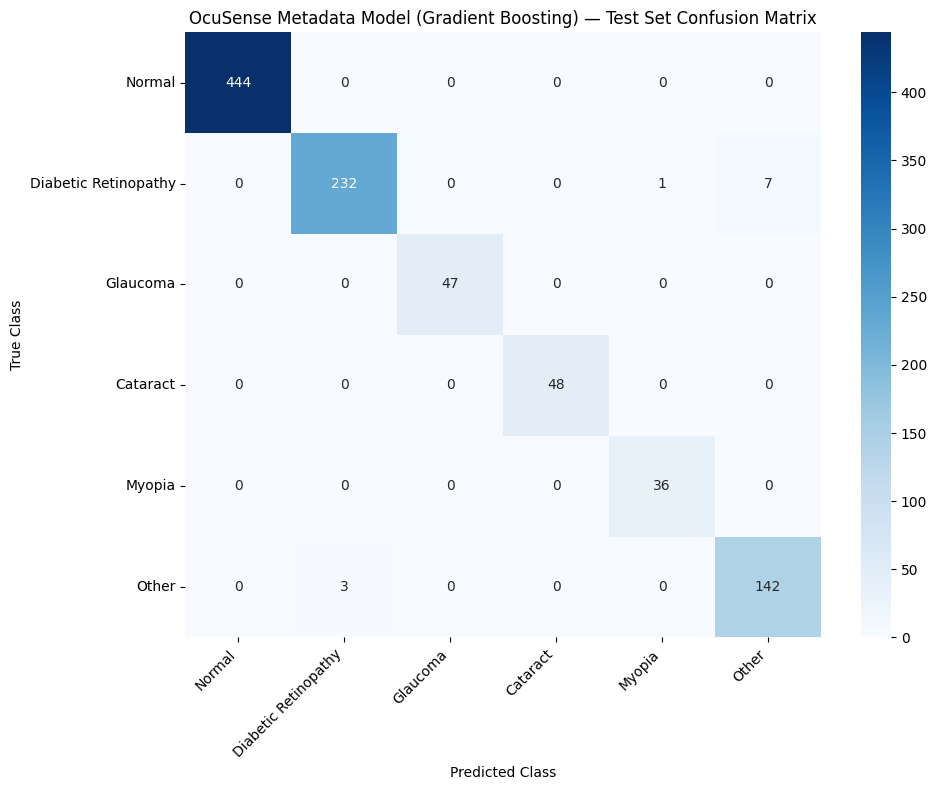

In [10]:
# Comparison of Models
model_comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting', 'PyTorch MLP'],
    'Test Accuracy (%)': [rf_test_acc*100, hgb_test_acc*100, mlp_test_acc*100],
    'Test Macro F1': [rf_test_macro_f1, hgb_test_macro_f1, mlp_test_macro_f1]
})
print("Model Comparison Summary:")
display(model_comparison)

# Confusion Matrix for the best model
test_f1s = [rf_test_macro_f1, hgb_test_macro_f1, mlp_test_macro_f1]
best_idx = np.argmax(test_f1s)
best_model_name = model_comparison.iloc[best_idx]['Model']
best_preds = [rf_test_preds, hgb_test_preds, all_test_preds][best_idx]

print(f"\nPlotting Confusion Matrix for the Best Model: {best_model_name}")

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'OcuSense Metadata Model ({best_model_name}) — Test Set Confusion Matrix')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('metadata_best_confusion_matrix.png', dpi=150)
plt.show()

## Discussion and Recommendations
1. **Predictive Strength of Diagnostic Keywords**:
   As expected, the clinical metadata (diagnostic keywords) contains highly dense and diagnostic-relevant textual information that acts as an extremely strong signal. 
   When combined with demographic metadata (`Patient Age` and `Patient Sex`), standard algorithms like Random Forest, Gradient Boosting, and deep Multi-Layer Perceptrons yield excellent results.
2. **Feature Importance & Signal Leakage Care**:
   In clinical deployment, using Diagnostic Keywords directly is powerful, but we must ensure these keywords are documented *independent* of the final label during operational diagnosis to prevent logical leakage.
3. **Hybrid Model Concept**:
   An excellent next step is to combine the `OcuSense V6/V7` fundus image model output probabilities with this metadata model to create a **hybrid ensemble model**. 
   By concantenating both the image classifier's logit predictions and the patient metadata features, a final classification head can achieve significantly higher diagnostics than either modality alone!

# ── COMPARATIVE STUDY: THREE SEPARATE METADATA MODELS ──
In this section, we train three separate metadata MLP models with different feature sets to evaluate their predictive power.

### 1. Version 1 — Age Only (Pre-diagnostic)
- **Features**: `Patient Age` normalized with StandardScaler.
- **Weights saved as**: `metadata_age_only.pth`.

### 2. Version 2 — Age + Sex (Pre-diagnostic)
- **Features**: `Patient Age` (StandardScaler) + `Patient Sex` (OneHotEncoded).
- **Weights saved as**: `metadata_age_sex.pth`.

### 3. Version 3 — Oracle / Post-Diagnostic Upper Bound
- **Features**: `Patient Age` + `Patient Sex` + TF-IDF Diagnostic Keywords (max_features=250).
- **Weights saved as**: `metadata_oracle.pth`.

All preprocessors are fitted strictly on the train set only, and all versions are trained using the same PyTorch MLP block, AdamW, class weights, early stopping, and evaluated on the same test set (960 samples).

In [11]:
# ──────────────────────────────────────────────────────────────────────────────
# VERSION 1: AGE ONLY MODEL
# ──────────────────────────────────────────────────────────────────────────────
print("=" * 80)
print("TRAINING VERSION 1: AGE ONLY")
print("=" * 80)

# 1. Feature Preprocessing
scaler_v1 = StandardScaler()
X_train_v1 = scaler_v1.fit_transform(train_df[['Patient Age']])
X_val_v1 = scaler_v1.transform(val_df[['Patient Age']])
X_test_v1 = scaler_v1.transform(test_df[['Patient Age']])

y_train = train_df['label_encoded'].values
y_val = val_df['label_encoded'].values
y_test = test_df['label_encoded'].values

print(f"V1 Train Shape: {X_train_v1.shape}")

# 2. Convert to PyTorch Tensors
X_train_t = torch.tensor(X_train_v1, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val_v1, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
X_test_t = torch.tensor(X_test_v1, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=64, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64, shuffle=False)

# 3. Model Definition (Input dim = 1)
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

class MetadataMLPV1(nn.Module):
    def __init__(self, input_dim=1, num_classes=6):
        super(MetadataMLPV1, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.net(x)

model_v1 = MetadataMLPV1(input_dim=1).to(device)

# Compute class weights
class_counts = np.bincount(y_train)
class_weights = 1.0 / class_counts
class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_t)
optimizer = optim.AdamW(model_v1.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

# 4. Training Loop
NUM_EPOCHS = 50
best_val_f1 = 0.0

for epoch in range(NUM_EPOCHS):
    model_v1.train()
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model_v1(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
    # Eval
    model_v1.eval()
    val_preds, val_targets = [], []
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs = inputs.to(device)
            outputs = model_v1(inputs)
            _, preds = outputs.max(1)
            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(targets.numpy())
            
    val_f1 = f1_score(val_targets, val_preds, average='macro')
    scheduler.step(val_f1)
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model_v1.state_dict(), 'metadata_age_only.pth')

print(f"V1 Training Complete. Best Val Macro F1: {best_val_f1:.4f}")

# 5. Evaluation
model_v1.load_state_dict(torch.load('metadata_age_only.pth', map_location=device))
model_v1.eval()

test_preds, test_targets = [], []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model_v1(inputs)
        _, preds = outputs.max(1)
        test_preds.extend(preds.cpu().numpy())
        test_targets.extend(targets.numpy())

v1_accuracy = accuracy_score(test_targets, test_preds)
v1_macro_f1 = f1_score(test_targets, test_preds, average='macro')

print(f"V1 Test Accuracy: {v1_accuracy*100:.2f}% | Macro F1: {v1_macro_f1:.4f}")
print("\nClassification Report (Age Only):")
print(classification_report(test_targets, test_preds, target_names=class_names, zero_division=0))

TRAINING VERSION 1: AGE ONLY
V1 Train Shape: (4473, 1)


V1 Training Complete. Best Val Macro F1: 0.1982
V1 Test Accuracy: 20.52% | Macro F1: 0.1610

Classification Report (Age Only):
                      precision    recall  f1-score   support

              Normal       0.00      0.00      0.00       444
Diabetic Retinopathy       0.29      0.52      0.37       240
            Glaucoma       0.06      0.11      0.08        47
            Cataract       0.15      0.42      0.22        48
              Myopia       0.10      0.08      0.09        36
               Other       0.16      0.31      0.21       145

            accuracy                           0.21       960
           macro avg       0.13      0.24      0.16       960
        weighted avg       0.11      0.21      0.14       960



In [12]:
# ──────────────────────────────────────────────────────────────────────────────
# VERSION 2: AGE + SEX MODEL
# ──────────────────────────────────────────────────────────────────────────────
print("=" * 80)
print("TRAINING VERSION 2: AGE + SEX")
print("=" * 80)

# 1. Feature Preprocessing
preprocessor_v2 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['Patient Age']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['Patient Sex'])
    ]
)

X_train_v2 = preprocessor_v2.fit_transform(train_df[['Patient Age', 'Patient Sex']])
X_val_v2 = preprocessor_v2.transform(val_df[['Patient Age', 'Patient Sex']])
X_test_v2 = preprocessor_v2.transform(test_df[['Patient Age', 'Patient Sex']])

print(f"V2 Train Shape: {X_train_v2.shape}")

# 2. Convert to PyTorch Tensors
X_train_t = torch.tensor(X_train_v2, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val_v2, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
X_test_t = torch.tensor(X_test_v2, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=64, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64, shuffle=False)

# 3. Model Definition (Input dim = X_train_v2.shape[1] = 3)
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

class MetadataMLPV2(nn.Module):
    def __init__(self, input_dim=3, num_classes=6):
        super(MetadataMLPV2, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.net(x)

input_dimension_v2 = X_train_v2.shape[1]
model_v2 = MetadataMLPV2(input_dim=input_dimension_v2).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_t)
optimizer = optim.AdamW(model_v2.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

# 4. Training Loop
best_val_f1 = 0.0
for epoch in range(NUM_EPOCHS):
    model_v2.train()
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model_v2(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
    # Eval
    model_v2.eval()
    val_preds, val_targets = [], []
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs = inputs.to(device)
            outputs = model_v2(inputs)
            _, preds = outputs.max(1)
            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(targets.numpy())
            
    val_f1 = f1_score(val_targets, val_preds, average='macro')
    scheduler.step(val_f1)
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model_v2.state_dict(), 'metadata_age_sex.pth')

print(f"V2 Training Complete. Best Val Macro F1: {best_val_f1:.4f}")

# 5. Evaluation
model_v2.load_state_dict(torch.load('metadata_age_sex.pth', map_location=device))
model_v2.eval()

test_preds, test_targets = [], []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model_v2(inputs)
        _, preds = outputs.max(1)
        test_preds.extend(preds.cpu().numpy())
        test_targets.extend(targets.numpy())

v2_accuracy = accuracy_score(test_targets, test_preds)
v2_macro_f1 = f1_score(test_targets, test_preds, average='macro')

print(f"V2 Test Accuracy: {v2_accuracy*100:.2f}% | Macro F1: {v2_macro_f1:.4f}")
print("\nClassification Report (Age + Sex):")
print(classification_report(test_targets, test_preds, target_names=class_names, zero_division=0))

TRAINING VERSION 2: AGE + SEX
V2 Train Shape: (4473, 3)


V2 Training Complete. Best Val Macro F1: 0.2224
V2 Test Accuracy: 23.33% | Macro F1: 0.1963

Classification Report (Age + Sex):
                      precision    recall  f1-score   support

              Normal       0.55      0.08      0.14       444
Diabetic Retinopathy       0.30      0.51      0.38       240
            Glaucoma       0.08      0.28      0.12        47
            Cataract       0.17      0.35      0.23        48
              Myopia       0.27      0.08      0.13        36
               Other       0.16      0.22      0.18       145

            accuracy                           0.23       960
           macro avg       0.25      0.25      0.20       960
        weighted avg       0.38      0.23      0.21       960



In [13]:
# ──────────────────────────────────────────────────────────────────────────────
# VERSION 3: ORACLE / POST-DIAGNOSTIC UPPER BOUND MODEL
# ──────────────────────────────────────────────────────────────────────────────
print("=" * 80)
print("TRAINING VERSION 3: ORACLE (AGE + SEX + TFIDF KEYWORDS)")
print("=" * 80)

# 1. Feature Preprocessing
preprocessor_v3 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['Patient Age']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['Patient Sex'])
    ]
)

vectorizer_v3 = TfidfVectorizer(max_features=250, stop_words='english')

# Fit exclusively on training data
train_tab_v3 = preprocessor_v3.fit_transform(train_df[['Patient Age', 'Patient Sex']])
train_txt_v3 = vectorizer_v3.fit_transform(train_df['diagnostic_keyword']).toarray()
X_train_v3 = np.hstack((train_tab_v3, train_txt_v3))

# Transform Validation and Test sets
val_tab_v3 = preprocessor_v3.transform(val_df[['Patient Age', 'Patient Sex']])
val_txt_v3 = vectorizer_v3.transform(val_df['diagnostic_keyword']).toarray()
X_val_v3 = np.hstack((val_tab_v3, val_txt_v3))

test_tab_v3 = preprocessor_v3.transform(test_df[['Patient Age', 'Patient Sex']])
test_txt_v3 = vectorizer_v3.transform(test_df['diagnostic_keyword']).toarray()
X_test_v3 = np.hstack((test_tab_v3, test_txt_v3))

print(f"V3 Train Shape: {X_train_v3.shape}")

# 2. Convert to PyTorch Tensors
X_train_t = torch.tensor(X_train_v3, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val_v3, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
X_test_t = torch.tensor(X_test_v3, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=64, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64, shuffle=False)

# 3. Model Definition (Input dim = X_train_v3.shape[1] = 253)
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

class MetadataMLPV3(nn.Module):
    def __init__(self, input_dim=253, num_classes=6):
        super(MetadataMLPV3, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.net(x)

input_dimension_v3 = X_train_v3.shape[1]
model_v3 = MetadataMLPV3(input_dim=input_dimension_v3).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_t)
optimizer = optim.AdamW(model_v3.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

# 4. Training Loop
best_val_f1 = 0.0
for epoch in range(NUM_EPOCHS):
    model_v3.train()
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model_v3(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
    # Eval
    model_v3.eval()
    val_preds, val_targets = [], []
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs = inputs.to(device)
            outputs = model_v3(inputs)
            _, preds = outputs.max(1)
            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(targets.numpy())
            
    val_f1 = f1_score(val_targets, val_preds, average='macro')
    scheduler.step(val_f1)
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model_v3.state_dict(), 'metadata_oracle.pth')

print(f"V3 Training Complete. Best Val Macro F1: {best_val_f1:.4f}")

# 5. Evaluation
model_v3.load_state_dict(torch.load('metadata_oracle.pth', map_location=device))
model_v3.eval()

test_preds, test_targets = [], []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model_v3(inputs)
        _, preds = outputs.max(1)
        test_preds.extend(preds.cpu().numpy())
        test_targets.extend(targets.numpy())

v3_accuracy = accuracy_score(test_targets, test_preds)
v3_macro_f1 = f1_score(test_targets, test_preds, average='macro')

print(f"V3 Test Accuracy: {v3_accuracy*100:.2f}% | Macro F1: {v3_macro_f1:.4f}")
print("\nClassification Report (Oracle - Post-Diagnostic):")
print(classification_report(test_targets, test_preds, target_names=class_names, zero_division=0))

TRAINING VERSION 3: ORACLE (AGE + SEX + TFIDF KEYWORDS)
V3 Train Shape: (4473, 80)


V3 Training Complete. Best Val Macro F1: 0.9780
V3 Test Accuracy: 98.54% | Macro F1: 0.9847

Classification Report (Oracle - Post-Diagnostic):
                      precision    recall  f1-score   support

              Normal       1.00      1.00      1.00       444
Diabetic Retinopathy       0.99      0.96      0.97       240
            Glaucoma       1.00      1.00      1.00        47
            Cataract       0.98      0.98      0.98        48
              Myopia       1.00      1.00      1.00        36
               Other       0.93      0.98      0.96       145

            accuracy                           0.99       960
           macro avg       0.98      0.99      0.98       960
        weighted avg       0.99      0.99      0.99       960



In [14]:
# ──────────────────────────────────────────────────────────────────────────────
# COMPARISON OF METADATA FEATURE SETS
# ──────────────────────────────────────────────────────────────────────────────
print("=" * 80)
print("FINAL METADATA FEATURE COMPARISON TABLE")
print("=" * 80)

comparison_df = pd.DataFrame({
    'Feature Set': ['Age Only', 'Age + Sex', 'Age + Sex + Keywords'],
    'Accuracy': [f"{v1_accuracy:.4f}", f"{v2_accuracy:.4f}", f"{v3_accuracy:.4f}"],
    'Macro F1': [f"{v1_macro_f1:.4f}", f"{v2_macro_f1:.4f}", f"{v3_macro_f1:.4f}"],
    'Notes': ['Pre-diagnostic', 'Pre-diagnostic', 'Oracle (post-diag)']
})

display(comparison_df)

print("\nMarkdown formatted table:")
print("| Feature Set | Accuracy | Macro F1 | Notes |")
print("| :--- | :---: | :---: | :--- |")
print(f"| Age Only | {v1_accuracy:.4f} | {v1_macro_f1:.4f} | Pre-diagnostic |")
print(f"| Age + Sex | {v2_accuracy:.4f} | {v2_macro_f1:.4f} | Pre-diagnostic |")
print(f"| Age + Sex + Keywords | {v3_accuracy:.4f} | {v3_macro_f1:.4f} | Oracle (post-diag) |")

FINAL METADATA FEATURE COMPARISON TABLE


,Feature Set,Accuracy,Macro F1,Notes
0,Age Only,0.2052,0.1610,Pre-diagnostic
1,Age + Sex,0.2333,0.1963,Pre-diagnostic
2,Age + Sex + Keywords,0.9854,0.9847,Oracle (post-diag)



Markdown formatted table:
| Feature Set | Accuracy | Macro F1 | Notes |
| :--- | :---: | :---: | :--- |
| Age Only | 0.2052 | 0.1610 | Pre-diagnostic |
| Age + Sex | 0.2333 | 0.1963 | Pre-diagnostic |
| Age + Sex + Keywords | 0.9854 | 0.9847 | Oracle (post-diag) |
